In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import matplotlib.ticker as mtick

# 1. Import dataset and look at the shape of the data #

In [3]:
df = pd.read_csv("../data/animal-shelter-intakes-and-outcomes.csv")

In [4]:
df.head()          # shows the first 5 rows

,Kennel ID,Animal ID,Animal Name,Animal Type,Primary Color,Secondary Color,Sex,DOB,Intake Date,Intake Condition,...,longitude,intake_is_dead,geopoint,intake_duration,is_current_month,outcome_is_dead,outcome_is_current,outcome_is_other,outcome_is_alive,was_outcome_alive
0,396410,A752361,NEZUKO,DOG,BLACK,TAN,Spayed,2019-04-01,2025-11-12,NORMAL,...,-118.116794,Alive on Intake,"33.8101914, -118.1167941",0.0,False,False,False,False,True,1
1,381378,A743938,NaN,CAT,BRN TABBY,NaN,Unknown,NaN,2025-06-26,UNDER AGE/WEIGHT,...,-118.116719,Alive on Intake,"33.8101831, -118.1167191",0.0,False,True,False,False,False,0
2,381379,A743939,NaN,CAT,BRN TABBY,NaN,Unknown,NaN,2025-06-26,UNDER AGE/WEIGHT,...,-118.116719,Alive on Intake,"33.8101831, -118.1167191",0.0,False,True,False,False,False,0
3,381380,A743940,NaN,CAT,BRN TABBY,NaN,Unknown,NaN,2025-06-26,UNDER AGE/WEIGHT,...,-118.116719,Alive on Intake,"33.8101831, -118.1167191",0.0,False,True,False,False,False,0
4,296878,A611040,COCO,RABBIT,WHITE,BROWN,Female,2016-07-13,2018-07-13,NORMAL,...,-118.116680,Alive on Intake,"33.8035331, -118.1166798",1.0,False,False,False,False,True,1


In [5]:
df.shape           # shows (number of rows, number of columns)

(53632, 29)

In [6]:
df.columns         # lists all column names

Index(['Kennel ID', 'Animal ID', 'Animal Name', 'Animal Type', 'Primary Color',
       'Secondary Color', 'Sex', 'DOB', 'Intake Date', 'Intake Condition',
       'Intake Type', 'Intake Subtype', 'Reason for Intake', 'Outcome Date',
       'Crossing', 'Jurisdiction', 'Outcome Type', 'Outcome Subtype',
       'latitude', 'longitude', 'intake_is_dead', 'geopoint',
       'intake_duration', 'is_current_month', 'outcome_is_dead',
       'outcome_is_current', 'outcome_is_other', 'outcome_is_alive',
       'was_outcome_alive'],
      dtype='object')

In [7]:
df.dtypes          # shows the data type of each column

Kennel ID               int64
Animal ID              object
Animal Name            object
Animal Type            object
Primary Color          object
Secondary Color        object
Sex                    object
DOB                    object
Intake Date            object
Intake Condition       object
Intake Type            object
Intake Subtype         object
Reason for Intake      object
Outcome Date           object
Crossing               object
Jurisdiction           object
Outcome Type           object
Outcome Subtype        object
latitude              float64
longitude             float64
intake_is_dead         object
geopoint               object
intake_duration       float64
is_current_month         bool
outcome_is_dead          bool
outcome_is_current       bool
outcome_is_other         bool
outcome_is_alive         bool
was_outcome_alive       int64
dtype: object

In [8]:
df.info()          # summary of columns, types, and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53632 entries, 0 to 53631
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Kennel ID           53632 non-null  int64  
 1   Animal ID           53632 non-null  object 
 2   Animal Name         31965 non-null  object 
 3   Animal Type         53632 non-null  object 
 4   Primary Color       53632 non-null  object 
 5   Secondary Color     25350 non-null  object 
 6   Sex                 53632 non-null  object 
 7   DOB                 46947 non-null  object 
 8   Intake Date         53632 non-null  object 
 9   Intake Condition    53632 non-null  object 
 10  Intake Type         53632 non-null  object 
 11  Intake Subtype      52886 non-null  object 
 12  Reason for Intake   3492 non-null   object 
 13  Outcome Date        53459 non-null  object 
 14  Crossing            53464 non-null  object 
 15  Jurisdiction        53631 non-null  object 
 16  Outc

In [9]:
df.isnull().sum()  # counts missing values in each column

Kennel ID                 0
Animal ID                 0
Animal Name           21667
Animal Type               0
Primary Color             0
Secondary Color       28282
Sex                       0
DOB                    6685
Intake Date               0
Intake Condition          0
Intake Type               0
Intake Subtype          746
Reason for Intake     50140
Outcome Date            173
Crossing                168
Jurisdiction              1
Outcome Type            191
Outcome Subtype        5651
latitude                  0
longitude                 0
intake_is_dead            0
geopoint                  0
intake_duration         173
is_current_month          0
outcome_is_dead           0
outcome_is_current        0
outcome_is_other          0
outcome_is_alive          0
was_outcome_alive         0
dtype: int64

# 2. Look at the target variables to determine how to clean the data #

In [11]:
print(df['Outcome Type'].value_counts())    # show all the possible outcomes and how frequent each one is

Outcome Type
RESCUE                     12683
ADOPTION                   11634
EUTHANASIA                  9871
TRANSFER                    7845
RETURN TO OWNER             5521
SHELTER, NEUTER, RETURN     1395
DIED                        1296
COMMUNITY CAT               1001
TRANSPORT                    675
RETURN TO WILD HABITAT       520
FOSTER TO ADOPT              342
HOMEFIRST                    143
DISPOSAL                     141
MISSING                      126
TRAP, NEUTER, RELEASE         98
RETURN TO RESCUE              71
DUPLICATE                     62
FOSTER                        17
Name: count, dtype: int64


In [12]:
print(df['Animal Type'].value_counts()) # show all animal types and how frequent each one is
print("\n")
print(df['Sex'].value_counts()) # show all animal seses and how frequent each one is
print("\n")
print(df['Intake Condition'].value_counts()) # show all intake conditions and how frequent each one is
print("\n")
print(df['Intake Type'].value_counts()) # show all intake types and how frequent each one is

Animal Type
CAT           25390
DOG           17292
BIRD           3835
OTHER          2637
WILD           2527
RABBIT         1026
REPTILE         585
GUINEA PIG      316
LIVESTOCK        21
AMPHIBIAN         3
Name: count, dtype: int64


Sex
Male        11856
Unknown     11546
Female      10762
Neutered    10453
Spayed       9015
Name: count, dtype: int64


Intake Condition
NORMAL                24054
UNDER AGE/WEIGHT      12126
INJURED  SEVERE        3734
ILL MILD               2430
ILL SEVERE             2392
INJURED  MODERATE      2216
INJURED  MILD          2001
ILL MODERATETE         1732
FRACTIOUS              1084
I/I REPORT              550
FERAL                   443
AGED                    265
BEHAVIOR  MODERATE      237
WELFARE SEIZURES        131
BEHAVIOR  SEVERE        124
BEHAVIOR  MILD          111
INTAKEEXAM                2
Name: count, dtype: int64


Intake Type
STRAY                    37622
WILDLIFE                  8367
OWNER SURRENDER           4708
WELFARE SEIZ

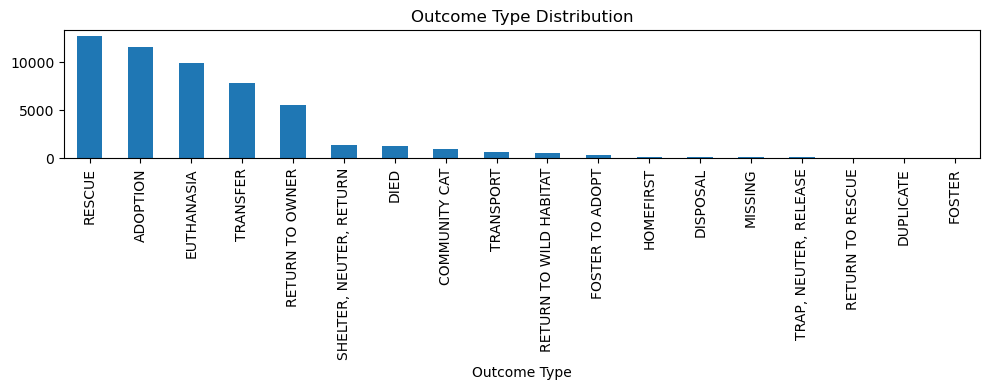

In [13]:
df['Outcome Type'].value_counts().plot(kind='bar', figsize=(10, 4), title='Outcome Type Distribution')
plt.tight_layout()
plt.show()

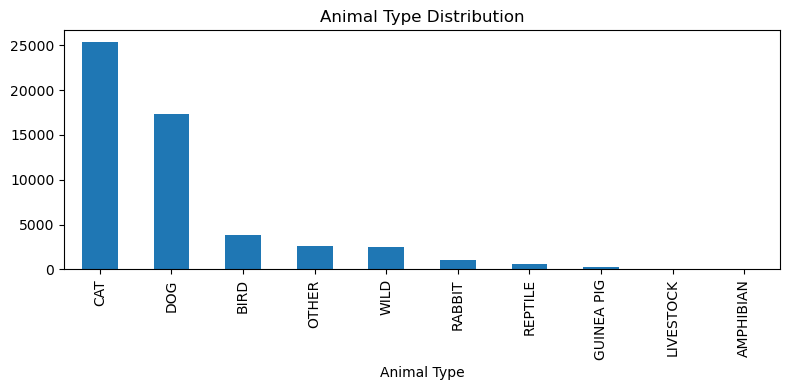

In [14]:
df['Animal Type'].value_counts().plot(kind='bar', figsize=(8, 4), title='Animal Type Distribution')
plt.tight_layout()
plt.show()

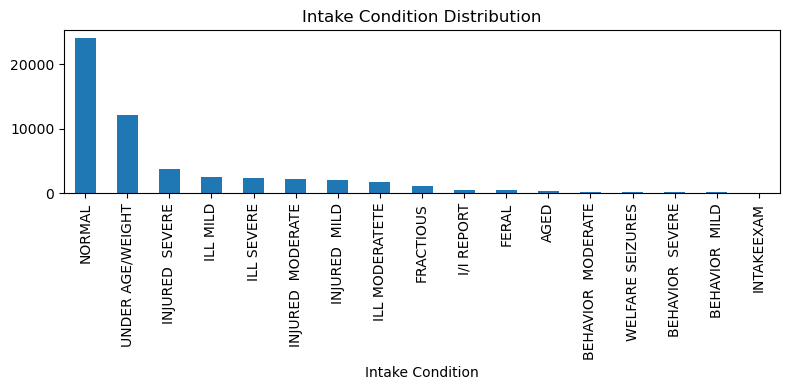

In [15]:
df['Intake Condition'].value_counts().plot(kind='bar', figsize=(8, 4), title='Intake Condition Distribution')
plt.tight_layout()
plt.show()

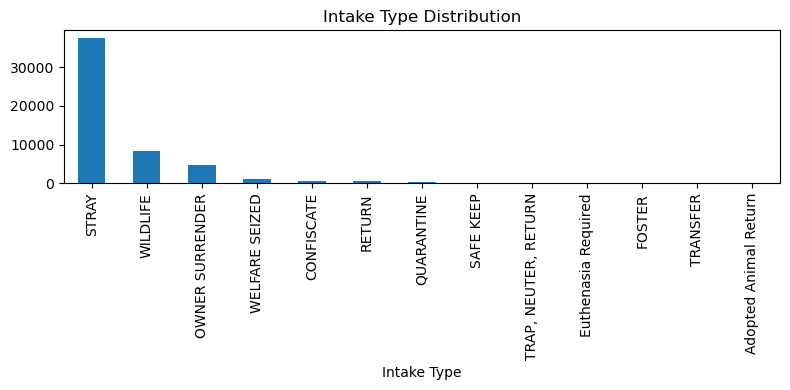

In [16]:
df['Intake Type'].value_counts().plot(kind='bar', figsize=(8, 4), title='Intake Type Distribution')
plt.tight_layout()
plt.show()

In [17]:
print(df['Intake Date'].head(10)) # get the format the dates are stored in, for later parsing
print("\n")
print(df['DOB'].head(10))

0    2025-11-12
1    2025-06-26
2    2025-06-26
3    2025-06-26
4    2018-07-13
5    2021-09-09
6    2019-04-13
7    2024-05-02
8    2019-08-15
9    2024-03-02
Name: Intake Date, dtype: object


0    2019-04-01
1           NaN
2           NaN
3           NaN
4    2016-07-13
5           NaN
6    2008-05-08
7    2019-05-02
8    2019-07-25
9    2023-08-07
Name: DOB, dtype: object


# 3. Data cleaning #

## 3.1 Drop rows that don't have outcome type ##

In [20]:
df = df.dropna(subset=['Outcome Type'])  # drop rows where outcome type is missing
print(df.shape)  # should go from 53632 to ~53441

(53441, 29)


## 3.2 Create a new column "adopted" ##

In [22]:
# create a new column (binary target label)
df['adopted'] = (df['Outcome Type'] == 'ADOPTION') | (df['Outcome Type'] == 'FOSTER TO ADOPT')
df['adopted'] = df['adopted'].astype(int)

print(df['adopted'].value_counts())

adopted
0    41465
1    11976
Name: count, dtype: int64


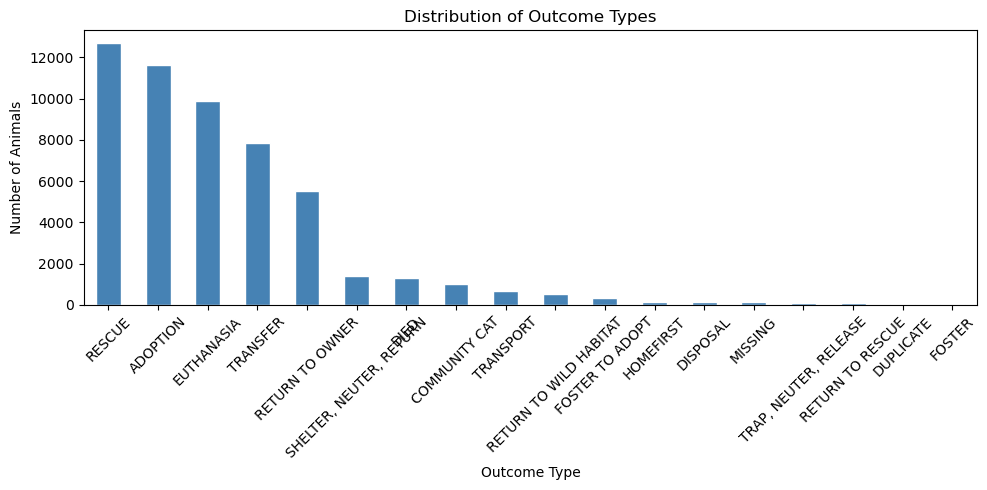

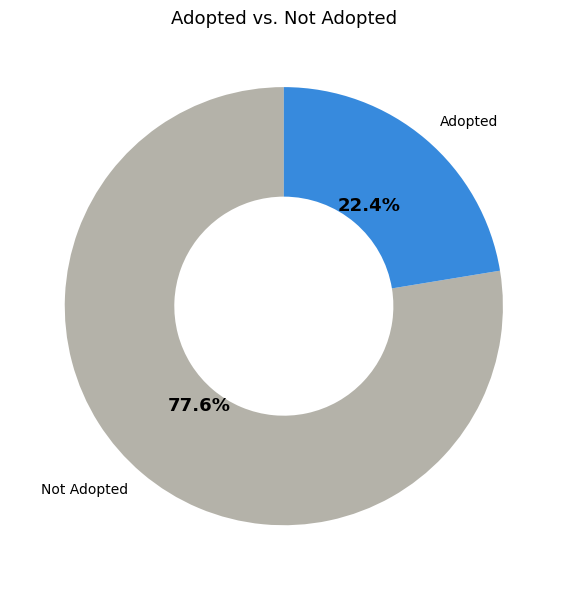

In [23]:
# Outcome type distribution
outcome_counts = df['Outcome Type'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
outcome_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Outcome Type')
ax.set_ylabel('Number of Animals')
ax.set_title('Distribution of Outcome Types')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Adopted vs not adopted class distribution
adopted_counts = df['adopted'].value_counts()
labels = ['Not Adopted', 'Adopted']
sizes = [adopted_counts[0], adopted_counts[1]]
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#B4B2A9', '#378ADD'],
    wedgeprops=dict(width=0.5)
)
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
ax.set_title('Adopted vs. Not Adopted', fontsize=13)
plt.tight_layout()
plt.show()

## 3.3 Drop columns we don't need ##

In [25]:
def is_real_name(name):
    if pd.isna(name):
        return 0
    name_clean = str(name).upper().strip()
    # Explicit placeholders
    if name_clean in ['UNKNOWN', 'NO NAME', 'NONE', 'N/A', 'NULL', 'NA']:
        return 0
    # Asterisk placeholder
    if name_clean == '*':
        return 0
    # Pure numeric entries (1, 2, 3... 99)
    if name_clean.isdigit():
        return 0
    # Pound sign + number (#1, #2 etc)
    if name_clean.startswith('#') and name_clean[1:].isdigit():
        return 0
    # P1-P9, R2 style shelter tracking codes
    if len(name_clean) == 2 and name_clean[0] in ['P', 'R', 'M'] and name_clean[1].isdigit():
        return 0
    # Everything else including two-letter real names like BO, TJ etc
    return 1

df['has_name'] = df['Animal Name'].apply(is_real_name)

print(df['has_name'].value_counts())
print(f"Has name rate: {df['has_name'].mean():.2%}")

has_name
1    31513
0    21928
Name: count, dtype: int64
Has name rate: 58.97%


In [26]:
# drop columns we don't need
cols_to_drop = [
    'Kennel ID', 'Animal ID', 'Animal Name',       # administrative, not predictive
    'Secondary Color',                               # ~53% missing
    'Reason for Intake',                             # ~93% missing
    'Outcome Date', 'Outcome Type', 'Outcome Subtype', # these are outcomes, not intake features
    'Crossing', 'Jurisdiction',                      # location admin info
    'latitude', 'longitude', 'geopoint',             # location, not useful
    'intake_is_dead', 'intake_duration',             # derived/leaky
    'outcome_is_dead', 'outcome_is_current',         # derived from outcome, leaky
    'outcome_is_other', 'outcome_is_alive',          # derived from outcome, leaky
    'was_outcome_alive',                             # derived from outcome, leaky
    'is_current_month',                              # administrative
    'Intake Subtype',                                # redundant with Intake Type
]

df = df.drop(columns=cols_to_drop)
print(df.shape)
print(df.columns.tolist())

(53441, 9)
['Animal Type', 'Primary Color', 'Sex', 'DOB', 'Intake Date', 'Intake Condition', 'Intake Type', 'adopted', 'has_name']


## 3.4 Create a new column "age_at_intake_days" ##

In [28]:
# create a new column "age_at_intake_days" - compute age where possible
df['Intake Date'] = pd.to_datetime(df['Intake Date'])
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')

# compute age in days at time of intake
df['age_at_intake_days'] = (df['Intake Date'] - df['DOB']).dt.days

print(df['age_at_intake_days'].describe())
print(df['age_at_intake_days'].isnull().sum())  # show how many are still missing

count    46766.000000
mean       807.619232
std       1163.755870
min      -3630.000000
25%         39.000000
50%        365.000000
75%       1096.000000
max      20818.000000
Name: age_at_intake_days, dtype: float64
6675


## 3.5 Create three new columns "intake_month", "intake_dayofweek", "intake_is_weekend" ##

In [30]:
# create three new columns - 'intake_month', 'intake_dayofweek', and 'intake_is_weekend'
df['intake_month'] = df['Intake Date'].dt.month
df['intake_dayofweek'] = df['Intake Date'].dt.dayofweek
df['intake_is_weekend'] = (df['intake_dayofweek'] >= 5).astype(int)

df = df.drop(columns=['Intake Date', 'DOB'])

## 3.6 Normalize all categorical columns ##

In [32]:
# Normalize all categorical columns uniformly
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].str.upper().str.strip().str.replace(r'\s+', ' ', regex=True)

print("All categorical columns normalized.")
print(df[cat_cols].head())

All categorical columns normalized.
  Animal Type Primary Color      Sex  Intake Condition Intake Type
0         DOG         BLACK   SPAYED            NORMAL       STRAY
1         CAT     BRN TABBY  UNKNOWN  UNDER AGE/WEIGHT       STRAY
2         CAT     BRN TABBY  UNKNOWN  UNDER AGE/WEIGHT       STRAY
3         CAT     BRN TABBY  UNKNOWN  UNDER AGE/WEIGHT       STRAY
4      RABBIT         WHITE   FEMALE            NORMAL       STRAY


# 4. Examine what we have so far to determine further changes and fixes to the data #

## 4.1. Address the Animal Type column - regroup animal types ##

In [35]:
def group_animal_type(t):
    if t in ['CAT', 'DOG', 'BIRD', 'WILD', 'RABBIT', 'REPTILE', 'GUINEA PIG']:
        return t
    else:
        return 'OTHER'

df['Animal Type'] = df['Animal Type'].apply(group_animal_type)
print(df['Animal Type'].value_counts())

Animal Type
CAT           25328
DOG           17178
BIRD           3831
OTHER          2660
WILD           2527
RABBIT         1018
REPTILE         583
GUINEA PIG      316
Name: count, dtype: int64


## 4.2. Address the "age_at_intake_days" column - fix unusual age values ##

In [37]:
# Fix negative ages: set to 0 since these are neonates
df.loc[df['age_at_intake_days'] < 0, 'age_at_intake_days'] = 0

# Verify the fix
print("Negative ages remaining:", (df['age_at_intake_days'] < 0).sum())
print("Records with age = 0:", (df['age_at_intake_days'] == 0).sum())

# Keep the suspiciously old records as-is, just verify them
print("\nOldest animals:")
print(df[df['age_at_intake_days'] > 10950][['Animal Type', 'Sex', 'Intake Condition', 'Intake Type', 'age_at_intake_days']])

Negative ages remaining: 0
Records with age = 0: 862

Oldest animals:
      Animal Type     Sex Intake Condition      Intake Type  \
9705         BIRD    MALE   ILL MODERATETE  OWNER SURRENDER   
12341     REPTILE    MALE           NORMAL            STRAY   
43165     REPTILE  FEMALE           NORMAL        SAFE KEEP   

       age_at_intake_days  
9705              20818.0  
12341             10957.0  
43165             18263.0  


## 4.3. Address the "Intake Condition" column - regroup intake conditions ##

In [39]:
# Before grouping — for reference
print(df['Intake Condition'].value_counts())

Intake Condition
NORMAL               23932
UNDER AGE/WEIGHT     12113
INJURED SEVERE        3730
ILL MILD              2418
ILL SEVERE            2387
INJURED MODERATE      2212
INJURED MILD          1993
ILL MODERATETE        1720
FRACTIOUS             1083
I/I REPORT             544
FERAL                  443
AGED                   265
BEHAVIOR MODERATE      236
WELFARE SEIZURES       130
BEHAVIOR SEVERE        124
BEHAVIOR MILD          109
INTAKEEXAM               2
Name: count, dtype: int64


In [40]:
def group_intake_condition(c):
    if c == 'NORMAL':
        return 'NORMAL'
    elif c == 'UNDER AGE/WEIGHT':
        return 'UNDER AGE/WEIGHT'
    elif c in ['INJURED SEVERE', 'ILL SEVERE']:        
        return 'ILL/INJURED SEVERE'
    elif c in ['INJURED MODERATE', 'ILL MODERATETE']:
        return 'ILL/INJURED MODERATE'
    elif c in ['INJURED MILD', 'ILL MILD']:
        return 'ILL/INJURED MILD'
    elif c in ['FERAL', 'FRACTIOUS']:
        return 'FERAL/FRACTIOUS'
    elif c in ['BEHAVIOR SEVERE', 'BEHAVIOR MODERATE', 'BEHAVIOR MILD']:
        return 'BEHAVIOR'
    else:
        return 'OTHER'

df['Intake Condition'] = df['Intake Condition'].apply(group_intake_condition)
print(df['Intake Condition'].value_counts())  # verify grouping result

Intake Condition
NORMAL                  23932
UNDER AGE/WEIGHT        12113
ILL/INJURED SEVERE       6117
ILL/INJURED MILD         4411
ILL/INJURED MODERATE     3932
FERAL/FRACTIOUS          1526
OTHER                     941
BEHAVIOR                  469
Name: count, dtype: int64


## 4.4. Address the "Intake Type" column - regroup intake types ##

In [42]:
# Before grouping — for reference
print(df['Intake Type'].value_counts())

Intake Type
STRAY                    37479
WILDLIFE                  8364
OWNER SURRENDER           4686
WELFARE SEIZED            1011
CONFISCATE                 678
RETURN                     603
QUARANTINE                 281
SAFE KEEP                  185
TRAP, NEUTER, RETURN       119
EUTHENASIA REQUIRED         21
FOSTER                       7
TRANSFER                     4
ADOPTED ANIMAL RETURN        3
Name: count, dtype: int64


In [43]:
def group_intake_type(t):
    if t == 'STRAY':
        return 'STRAY'
    elif t == 'WILDLIFE':
        return 'WILDLIFE'
    elif t == 'OWNER SURRENDER':
        return 'OWNER SURRENDER'
    elif t in ['WELFARE SEIZED', 'CONFISCATE']:
        return 'SEIZED/CONFISCATE'
    elif t in ['RETURN', 'ADOPTED ANIMAL RETURN']:
        return 'RETURN'
    elif t in ['QUARANTINE', 'SAFE KEEP']:
        return 'HOLDING'
    else:
        return 'OTHER'

df['Intake Type'] = df['Intake Type'].apply(group_intake_type)
print(df['Intake Type'].value_counts())  # verify grouping result

Intake Type
STRAY                37479
WILDLIFE              8364
OWNER SURRENDER       4686
SEIZED/CONFISCATE     1689
RETURN                 606
HOLDING                466
OTHER                  151
Name: count, dtype: int64


## 4.5. Address the "Primary Color" column - regrouped primary colors ##

In [45]:
# Before grouping — for reference
print(f"Unique colors: {df['Primary Color'].nunique()}")
print(df['Primary Color'].value_counts().to_string())

Unique colors: 85
Primary Color
BLACK         13489
GRAY           7109
WHITE          6505
BROWN          6369
BRN TABBY      4023
TAN            2505
GRAY TABBY     2156
ORG TABBY      1561
ORANGE          955
CALICO          940
TORTIE          839
TRICOLOR        582
BR BRINDLE      560
PINK            549
CREAM           449
BLUE            423
GREEN           410
RED             408
SEAL PT         383
YELLOW          246
FAWN            235
UNKNOWN         227
TORTIE DIL      197
LYNX PT         189
CALICO DIL      184
GOLD            180
CALICO TAB      146
CRM TABBY       138
CHOCOLATE       126
BLONDE          120
BLK TABBY       112
FLAME PT         94
BL BRINDLE       91
SNOWSHOE         91
CHOC PT          75
SILVER           74
TORBI            60
BLUE PT          53
SEAL             44
BLK SMOKE        39
LILAC PT         37
BLUE MERLE       35
BRN MERLE        29
APRICOT          28
SLVR TABBY       27
S-T PT           25
GRAY TIGER       24
RED MERLE        24
BUFF    

In [46]:
def group_color(c):
    c = str(c).upper().strip()
    
    # Point colorations (Siamese-type)
    if 'PT' in c or 'POINT' in c:
        return 'POINT'
    
    # Tabby and tiger patterns
    elif 'TABBY' in c or 'TIGER' in c:
        return 'TABBY'
    
    # Calico variations
    elif 'CALICO' in c:
        return 'CALICO'
    
    # Tortie variations
    elif 'TORTIE' in c or 'TORBI' in c:
        return 'TORTIE'
    
    # Multi-colored patterns (merle, brindle, tricolor)
    elif 'MERLE' in c or 'BRINDLE' in c or 'BRIND' in c or c == 'TRICOLOR':
        return 'MULTI-COLORED'
    
    # Solid black
    elif c == 'BLACK':
        return 'BLACK'
    
    # White and pink
    elif c in ['WHITE', 'PINK']:
        return 'WHITE/PINK'
    
    # Gray, blue, silver tones
    elif c in ['GRAY', 'GREY', 'BLUE', 'SILVER', 'BLK SMOKE', 'BLUE CREAM', 'SEAL', 'BLUE FAWN']:
        return 'GRAY/BLUE/SILVER'
    
    # Brown and tan warm tones
    elif c in ['BROWN', 'CHOCOLATE', 'LIVER', 'LIVER TICK', 'TAN', 'FAWN', 'BUFF', 'SABLE']:
        return 'BROWN/TAN'
    
    # Light and warm tones
    elif c in ['CREAM', 'BLONDE', 'APRICOT', 'PEACH', 'WHEAT', 'ORANGE', 'RED', 'GOLD', 'YELLOW', 'FLAME']:
        return 'LIGHT/WARM'
    
    # Everything else including GREEN, PURPLE, UNKNOWN
    else:
        return 'OTHER'

df['Primary Color'] = df['Primary Color'].apply(group_color)
print(df['Primary Color'].value_counts())

Primary Color
BLACK               13489
BROWN/TAN            9289
TABBY                8074
GRAY/BLUE/SILVER     7697
WHITE/PINK           7054
LIGHT/WARM           2407
MULTI-COLORED        1348
CALICO               1270
TORTIE               1104
POINT                 960
OTHER                 749
Name: count, dtype: int64


In [47]:
# Overall adoption rate for reference
overall_rate = df['adopted'].mean()
print(f"Overall adoption rate: {overall_rate:.2%}")

# Adoption rate by animal type
print("\nAdoption rate by Animal Type:")
print(df.groupby('Animal Type')['adopted'].mean().sort_values(ascending=False).map('{:.2%}'.format))

# Adoption rate by sex
print("\nAdoption rate by Sex:")
print(df.groupby('Sex')['adopted'].mean().sort_values(ascending=False).map('{:.2%}'.format))

# Adoption rate by intake condition
print("\nAdoption rate by Intake Condition:")
print(df.groupby('Intake Condition')['adopted'].mean().sort_values(ascending=False).map('{:.2%}'.format))

# Adoption rate by intake type
print("\nAdoption rate by Intake Type:")
print(df.groupby('Intake Type')['adopted'].mean().sort_values(ascending=False).map('{:.2%}'.format))

# Adoption rate by has_name
print("\nAdoption rate by Has Name:")
print(df.groupby('has_name')['adopted'].mean().map('{:.2%}'.format))

# Age at intake summary for adopted vs not adopted
print("\nAge at intake (days) — Adopted vs Not Adopted:")
print(df.groupby('adopted')['age_at_intake_days'].describe())

Overall adoption rate: 22.41%

Adoption rate by Animal Type:
Animal Type
DOG           29.36%
GUINEA PIG    27.85%
RABBIT        27.60%
CAT           25.36%
REPTILE        4.29%
BIRD           1.96%
OTHER          1.54%
WILD           0.00%
Name: adopted, dtype: object

Adoption rate by Sex:
Sex
SPAYED      51.80%
NEUTERED    50.52%
FEMALE       9.05%
MALE         8.51%
UNKNOWN      0.91%
Name: adopted, dtype: object

Adoption rate by Intake Condition:
Intake Condition
OTHER                   31.99%
NORMAL                  31.54%
BEHAVIOR                27.93%
ILL/INJURED MILD        22.92%
UNDER AGE/WEIGHT        16.76%
ILL/INJURED MODERATE    13.12%
FERAL/FRACTIOUS         12.91%
ILL/INJURED SEVERE       3.97%
Name: adopted, dtype: object

Adoption rate by Intake Type:
Intake Type
RETURN               67.33%
OWNER SURRENDER      31.78%
STRAY                25.68%
SEIZED/CONFISCATE    23.21%
HOLDING               8.58%
OTHER                 3.97%
WILDLIFE              0.19%
Name: adop

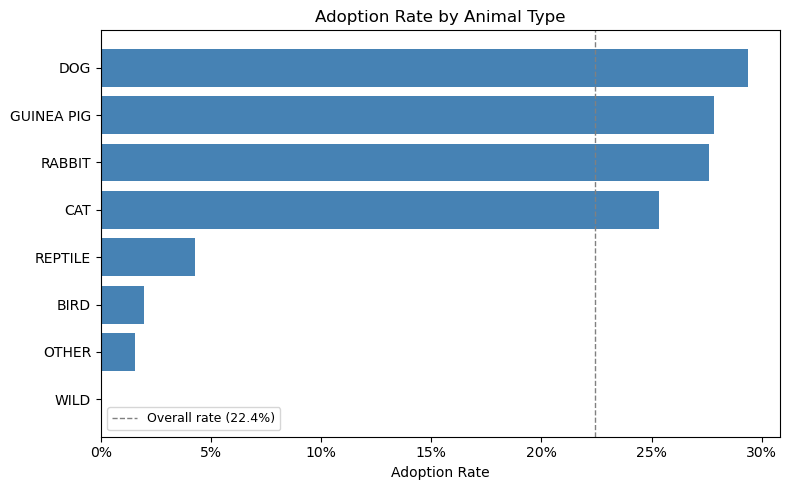

In [48]:
# --- Figure: Adoption rate by Animal Type ---
fig, ax = plt.subplots(figsize=(8, 5))
rates = df.groupby('Animal Type')['adopted'].mean().sort_values()
bars = ax.barh(rates.index, rates.values, color='steelblue')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.axvline(df['adopted'].mean(), color='gray', linestyle='--',
           linewidth=1, label=f'Overall rate ({df["adopted"].mean():.1%})')
ax.set_xlabel('Adoption Rate')
ax.set_title('Adoption Rate by Animal Type')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

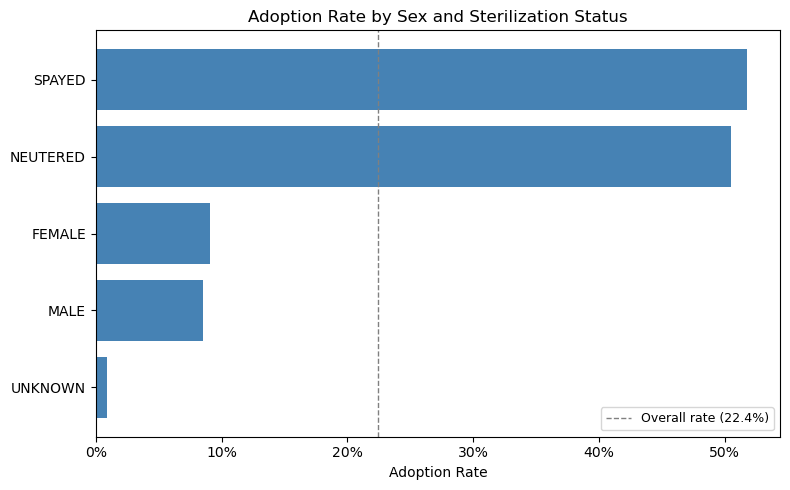

In [49]:
# --- Figure: Adoption rate by Sex / Sterilization Status ---
fig, ax = plt.subplots(figsize=(8, 5))
rates = df.groupby('Sex')['adopted'].mean().sort_values()
ax.barh(rates.index, rates.values, color='steelblue')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.axvline(df['adopted'].mean(), color='gray', linestyle='--',
           linewidth=1, label=f'Overall rate ({df["adopted"].mean():.1%})')
ax.set_xlabel('Adoption Rate')
ax.set_title('Adoption Rate by Sex and Sterilization Status')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

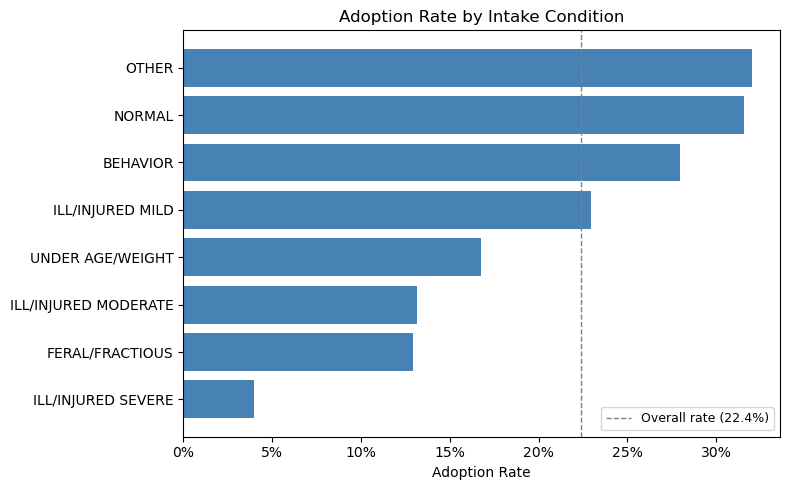

In [50]:
# --- Figure: Adoption rate by Intake Condition ---
fig, ax = plt.subplots(figsize=(8, 5))
rates = df.groupby('Intake Condition')['adopted'].mean().sort_values()
ax.barh(rates.index, rates.values, color='steelblue')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.axvline(df['adopted'].mean(), color='gray', linestyle='--',
           linewidth=1, label=f'Overall rate ({df["adopted"].mean():.1%})')
ax.set_xlabel('Adoption Rate')
ax.set_title('Adoption Rate by Intake Condition')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

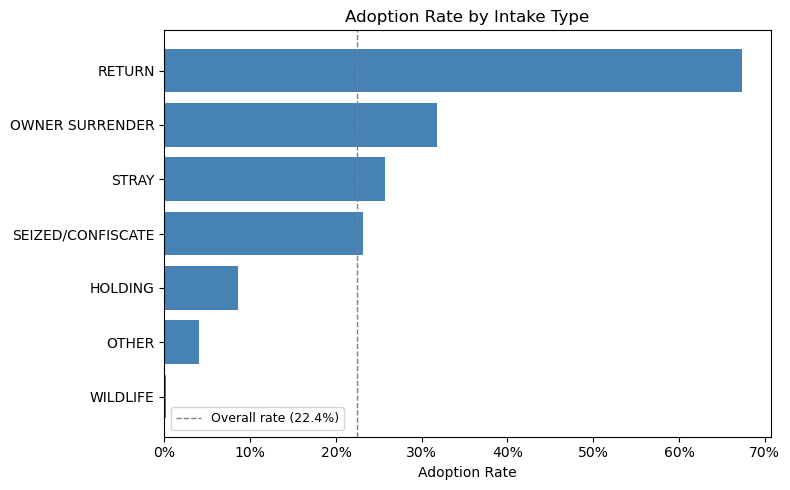

In [51]:
# --- Figure: Adoption rate by Intake Type ---
fig, ax = plt.subplots(figsize=(8, 5))
rates = df.groupby('Intake Type')['adopted'].mean().sort_values()
ax.barh(rates.index, rates.values, color='steelblue')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.axvline(df['adopted'].mean(), color='gray', linestyle='--',
           linewidth=1, label=f'Overall rate ({df["adopted"].mean():.1%})')
ax.set_xlabel('Adoption Rate')
ax.set_title('Adoption Rate by Intake Type')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

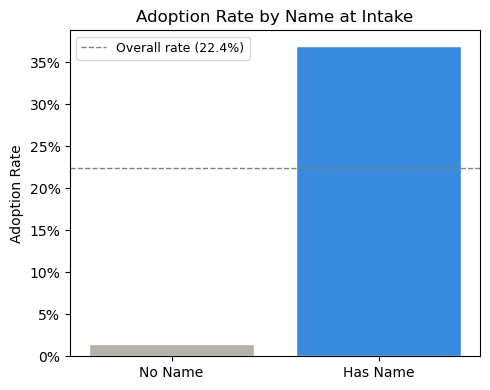

In [52]:
# --- Figure: Adoption rate by Has Name ---
fig, ax = plt.subplots(figsize=(5, 4))
rates = df.groupby('has_name')['adopted'].mean()
ax.bar(['No Name', 'Has Name'], rates.values, color=['#B4B2A9', '#378ADD'],
       edgecolor='white')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.axhline(df['adopted'].mean(), color='gray', linestyle='--',
           linewidth=1, label=f'Overall rate ({df["adopted"].mean():.1%})')
ax.set_ylabel('Adoption Rate')
ax.set_title('Adoption Rate by Name at Intake')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

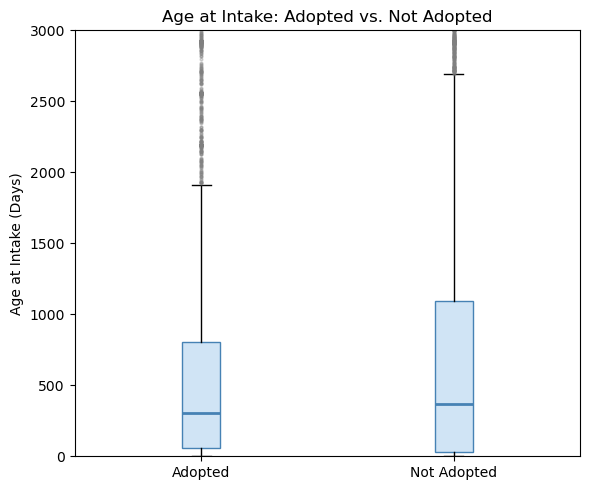

In [53]:
# --- Figure: Age at intake box plot ---
adopted_ages = df[df['adopted'] == 1]['age_at_intake_days'].dropna()
not_adopted_ages = df[df['adopted'] == 0]['age_at_intake_days'].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(
    [adopted_ages, not_adopted_ages],
    tick_labels=['Adopted', 'Not Adopted'],
    patch_artist=True,
    boxprops=dict(facecolor='#D0E4F5', color='steelblue'),
    medianprops=dict(color='steelblue', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3,
                    markerfacecolor='gray', markeredgecolor='gray')
)
ax.set_ylabel('Age at Intake (Days)')
ax.set_title('Age at Intake: Adopted vs. Not Adopted')
ax.set_ylim(0, 3000)
plt.tight_layout()
plt.show()

## 4.6 Address "intake_month" and "intake_dayofweek" - encode cyclical features using sine and cosine transformations ##

In [55]:
# For intake_month
df['intake_month_sin'] = np.sin(2 * np.pi * df['intake_month'] / 12)
df['intake_month_cos'] = np.cos(2 * np.pi * df['intake_month'] / 12)

# For intake_dayofweek
df['intake_dayofweek_sin'] = np.sin(2 * np.pi * df['intake_dayofweek'] / 7)
df['intake_dayofweek_cos'] = np.cos(2 * np.pi * df['intake_dayofweek'] / 7)

df = df.drop(columns=['intake_month', 'intake_dayofweek'])

## 4.7 Change all column names to lowercase ##

In [57]:
df = df.rename(columns={
    'Animal Type': 'animal_type',
    'Primary Color': 'primary_color',
    'Sex': 'sex',
    'Intake Condition': 'intake_condition',
    'Intake Type': 'intake_type'
})
print(df.columns.tolist())

['animal_type', 'primary_color', 'sex', 'intake_condition', 'intake_type', 'adopted', 'has_name', 'age_at_intake_days', 'intake_is_weekend', 'intake_month_sin', 'intake_month_cos', 'intake_dayofweek_sin', 'intake_dayofweek_cos']


In [58]:
# Note: age_at_intake_days shows missing values here intentionally.
# These are filled after train/test split using training set medians only
# to prevent data leakage. See section 5.5.
print(df.shape)
print("\n")
print(df.isnull().sum())
print("\n")
print(df.dtypes)
print("\n")
print(df.head())

(53441, 13)


animal_type                0
primary_color              0
sex                        0
intake_condition           0
intake_type                0
adopted                    0
has_name                   0
age_at_intake_days      6675
intake_is_weekend          0
intake_month_sin           0
intake_month_cos           0
intake_dayofweek_sin       0
intake_dayofweek_cos       0
dtype: int64


animal_type              object
primary_color            object
sex                      object
intake_condition         object
intake_type              object
adopted                   int64
has_name                  int64
age_at_intake_days      float64
intake_is_weekend         int64
intake_month_sin        float64
intake_month_cos        float64
intake_dayofweek_sin    float64
intake_dayofweek_cos    float64
dtype: object


  animal_type primary_color      sex  intake_condition intake_type  adopted  \
0         DOG         BLACK   SPAYED            NORMAL       STRAY        0   
1   

# 5. Preprocessing and Train/Test Split ##

## 5.1 Separate features and target ##

In [61]:
X = df.drop(columns=['adopted'])
y = df['adopted']

print(X.shape)
print(y.shape)

(53441, 12)
(53441,)


## 5.2 Build a preprocessing pipeline ##

In [63]:
categorical_cols = ['animal_type', 'primary_color', 'sex', 'intake_condition', 'intake_type']
scale_cols = ['age_at_intake_days']
passthrough_cols = ['intake_month_sin', 'intake_month_cos', 'intake_dayofweek_sin', 'intake_dayofweek_cos', 'has_name', 'intake_is_weekend']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), scale_cols),
    ('cyc', 'passthrough', passthrough_cols)
])

## 5.3 Train/test split ##

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training adoption rate: {y_train.mean():.2%}")
print(f"Test adoption rate: {y_test.mean():.2%}")

Training set: (42752, 12)
Test set: (10689, 12)
Training adoption rate: 22.41%
Test adoption rate: 22.41%


## 5.4 Fill any remaining NaNs with UNKNOWN as safety net ##

In [67]:
# Safety net applied directly to train/test sets
for col in categorical_cols:
    X_train[col] = X_train[col].fillna('UNKNOWN')
    X_test[col] = X_test[col].fillna('UNKNOWN')

print(X_train[categorical_cols].isnull().sum())
print(X_test[categorical_cols].isnull().sum())

animal_type         0
primary_color       0
sex                 0
intake_condition    0
intake_type         0
dtype: int64
animal_type         0
primary_color       0
sex                 0
intake_condition    0
intake_type         0
dtype: int64


## 5.5 Fill missing ages in training set using training medians ##

In [69]:
# Compute per-animal-type median ages from training set only
train_medians = X_train.groupby('animal_type')['age_at_intake_days'].median()
global_train_median = X_train['age_at_intake_days'].median()

print("Per-animal-type medians from training set:")
print(train_medians)
print(f"\nGlobal training median: {global_train_median}")

# Fill missing ages in training set using training medians
def fill_age(row, medians, global_median):
    if pd.isna(row['age_at_intake_days']):
        animal = row['animal_type']
        return medians[animal] if animal in medians.index else global_median
    return row['age_at_intake_days']

X_train = X_train.copy()
X_test = X_test.copy()

X_train['age_at_intake_days'] = X_train.apply(
    lambda row: fill_age(row, train_medians, global_train_median), axis=1)

# Fill missing ages in test set using TRAINING medians only
X_test['age_at_intake_days'] = X_test.apply(
    lambda row: fill_age(row, train_medians, global_train_median), axis=1)

# Verify no missing ages remain
print(f"\nMissing ages in train: {X_train['age_at_intake_days'].isnull().sum()}")
print(f"Missing ages in test: {X_test['age_at_intake_days'].isnull().sum()}")

Per-animal-type medians from training set:
animal_type
BIRD           365.0
CAT             61.0
DOG           1095.0
GUINEA PIG     365.0
OTHER           61.0
RABBIT         365.0
REPTILE        730.0
WILD           122.0
Name: age_at_intake_days, dtype: float64

Global training median: 365.0

Missing ages in train: 0
Missing ages in test: 0


## 5.6 Apply preprocessing pipeline ##

In [71]:
# Apply preprocessing pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [72]:
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train_processed shape: (42752, 46)
X_test_processed shape: (10689, 46)
y_train shape: (42752,)
y_test shape: (10689,)


In [73]:
# Get feature names from preprocessor
cat_feature_names = preprocessor.named_transformers_['cat']\
    .get_feature_names_out(categorical_cols).tolist()
num_feature_names = scale_cols
cyc_feature_names = passthrough_cols

all_feature_names = cat_feature_names + num_feature_names + cyc_feature_names
print(f"Total features: {len(all_feature_names)}")
print("\nAll feature names:")
for name in all_feature_names:
    print(f"  {name}")

Total features: 46

All feature names:
  animal_type_BIRD
  animal_type_CAT
  animal_type_DOG
  animal_type_GUINEA PIG
  animal_type_OTHER
  animal_type_RABBIT
  animal_type_REPTILE
  animal_type_WILD
  primary_color_BLACK
  primary_color_BROWN/TAN
  primary_color_CALICO
  primary_color_GRAY/BLUE/SILVER
  primary_color_LIGHT/WARM
  primary_color_MULTI-COLORED
  primary_color_OTHER
  primary_color_POINT
  primary_color_TABBY
  primary_color_TORTIE
  primary_color_WHITE/PINK
  sex_FEMALE
  sex_MALE
  sex_NEUTERED
  sex_SPAYED
  sex_UNKNOWN
  intake_condition_BEHAVIOR
  intake_condition_FERAL/FRACTIOUS
  intake_condition_ILL/INJURED MILD
  intake_condition_ILL/INJURED MODERATE
  intake_condition_ILL/INJURED SEVERE
  intake_condition_NORMAL
  intake_condition_OTHER
  intake_condition_UNDER AGE/WEIGHT
  intake_type_HOLDING
  intake_type_OTHER
  intake_type_OWNER SURRENDER
  intake_type_RETURN
  intake_type_SEIZED/CONFISCATE
  intake_type_STRAY
  intake_type_WILDLIFE
  age_at_intake_days
  i

In [74]:
X_train.to_csv("../artifacts/X_train_raw.csv", index=False)
X_test.to_csv("../artifacts/X_test_raw.csv", index=False)
y_train.to_csv("../artifacts/y_train.csv", index=False)
y_test.to_csv("../artifacts/y_test.csv", index=False)
print("Raw (unencoded) train and test sets saved successfully.")

Raw (unencoded) train and test sets saved successfully.


In [75]:
# Save processed arrays with feature names
pd.DataFrame(X_train_processed, columns=all_feature_names)\
    .to_csv("../artifacts/X_train_processed.csv", index=False)
pd.DataFrame(X_test_processed, columns=all_feature_names)\
    .to_csv("../artifacts/X_test_processed.csv", index=False)
print("Processed train and test sets saved successfully.")

Processed train and test sets saved successfully.


In [76]:
import joblib
joblib.dump(preprocessor, '../artifacts/preprocessor.joblib')
print("Preprocessor saved.")

Preprocessor saved.
